# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 20}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=2,gen_verb=False)

Iteration #0...
Mean loss: 6.682724033680217e+33
Parents indexes: [[0 3]
 [3 0]
 [2 0]
 [0 3]
 [0 1]
 [6 0]
 [0 2]
 [2 0]]
Selection Probabilities: [4.58145882e-01 1.75231775e-01 9.33163710e-02 8.94979047e-02
 8.15912982e-02 4.05738069e-02 2.56191283e-02 2.22687793e-02
 8.42142117e-03 2.44995349e-03 1.31642570e-03 7.53314426e-04
 4.59273846e-04 2.50258130e-04 4.09565331e-05 2.60565775e-05
 2.49592205e-05 1.22855682e-05 1.50301370e-07 2.31847292e-13]
Inverse losses: [1.17853176e-02 4.50765182e-03 2.40046481e-03 2.30223881e-03
 2.09884973e-03 1.04371821e-03 6.59024942e-04 5.72840763e-04
 2.16632141e-04 6.30224589e-05 3.38636569e-05 1.93782158e-05
 1.18143333e-05 6.43762535e-06 1.05356344e-06 6.70277861e-07
 6.42049512e-07 3.16033231e-07 3.86634356e-09 5.96402605e-15]
Iteration #10...
Mean loss: 2355348.843260843
Parents indexes: [[1 6]
 [3 1]
 [7 0]
 [4 9]
 [1 4]
 [4 2]
 [4 3]
 [3 0]]
Selection Probabilities: [1.94249299e-01 1.78681885e-01 1.43362095e-01 1.20553943e-01
 9.82210611e-02 8.

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 16


In [5]:
s = copy.deepcopy(solutions)
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    print(f'loss:{loss}')

Solution #0
Input: [0, 0] -> Output: 1.0354273831169996
Target distance:1.149419564149536
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 1.7705778529701928
Target distance:0.3525868342604313
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 1.4956398924877568
Target distance:0.0603482966355815
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: 1.4633446029629955
Target distance:4.585497284954765
Volume cost:1.7485144457345807e-06
loss:1.0164907676556632
Solution #1
Input: [0, 0] -> Output: -1.2094269963694146
Target distance:2.1395312498257986
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: -0.7295695631739971
Target distance:8.948539016235232
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: -0.7441477756911317
Target distance:9.25407710626808
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: -0.6536183562620821
Target distance:0.18251432718865607
Volume cost:1.7485144457345807e-06
loss:1.9847466811036774
Solution #2
Inpu

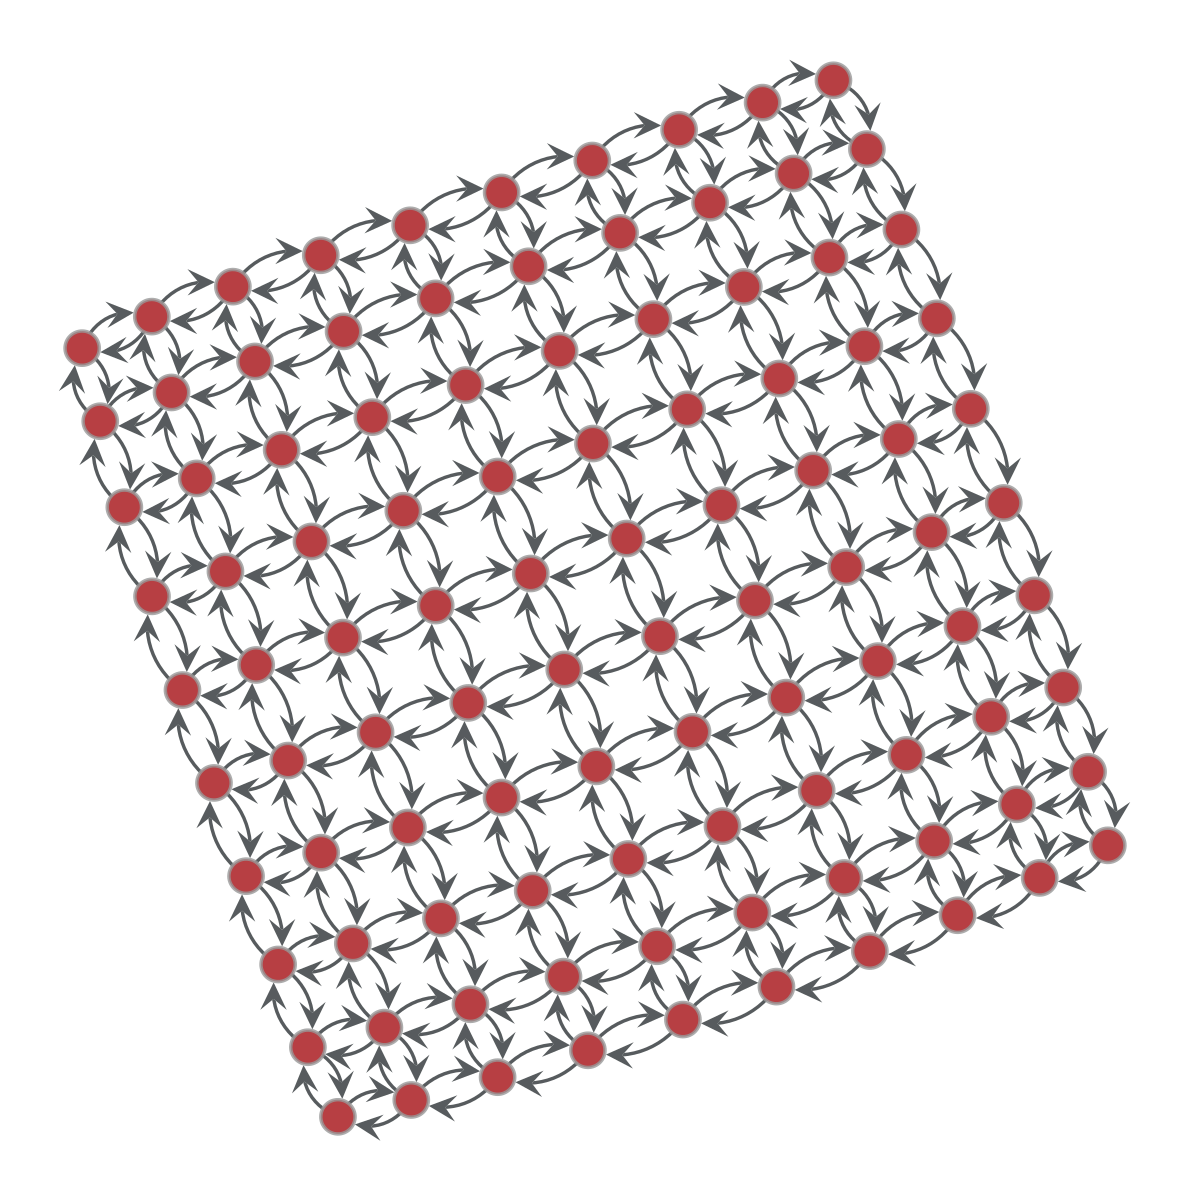

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fbae8b2f930, at 0x7fbae8b4d470>

In [6]:
graph_draw(s[0].G)

In [7]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [8]:
np.array([sol.loss for sol in s])

array([ 1.38898448,  2.14913484, 67.02023851,  0.53772266,  0.95160285,
        0.76426629,  0.75860793,  0.49292432,  0.45280754,  0.69396547,
        0.57614539,  0.28303713,  5.80581631, 55.85886707,  0.94513004,
       17.59389322,  0.96873203,  0.72636265, 27.25601455,  0.88344343])

In [9]:
for input in par['input_set']:
    output = m.ff(input,s[0],par)
    print(f'Input:{input} -> Output:{output}')

Input:[0, 0] -> Output:1.2661850375065693
Input:[0, 1] -> Output:1.5573278382723033
Input:[1, 0] -> Output:1.4133667948169821
Input:[1, 1] -> Output:1.2510948138531945


In [10]:
mean_loss = np.mean(np.array([sol.loss for sol in s]))
print(mean_loss)

9.305384836905496


In [11]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

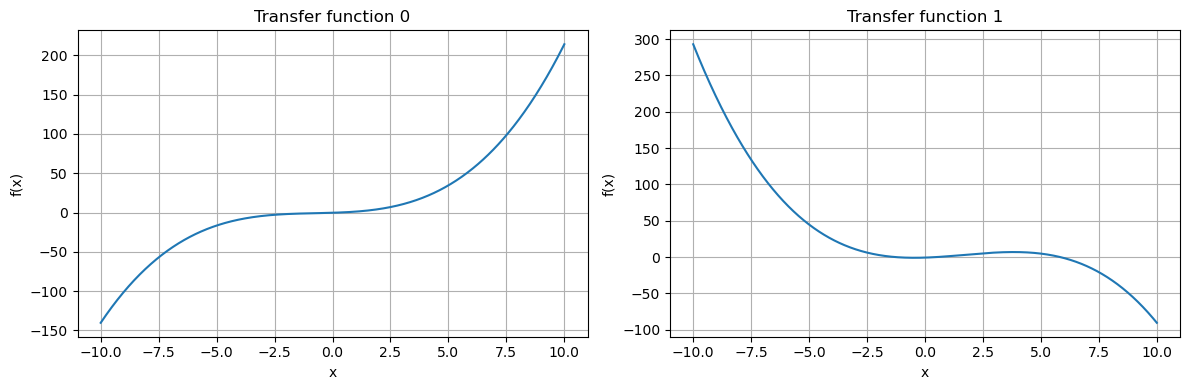

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

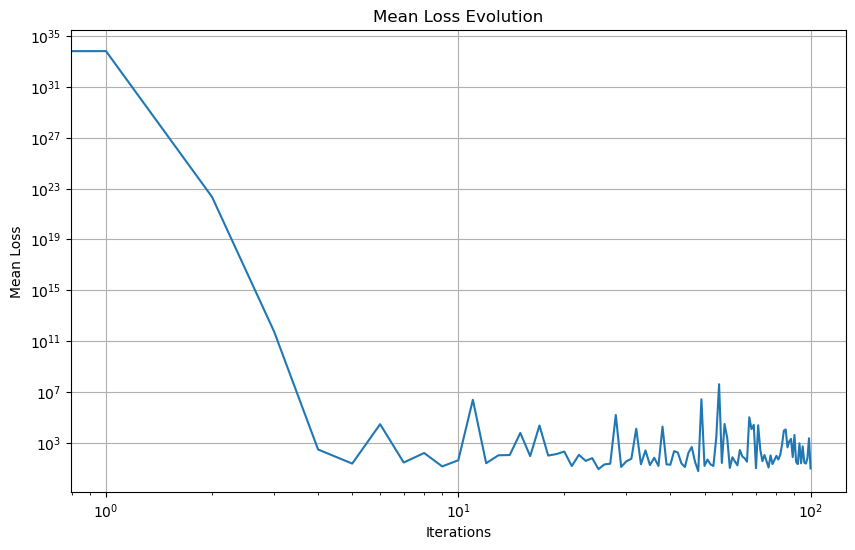

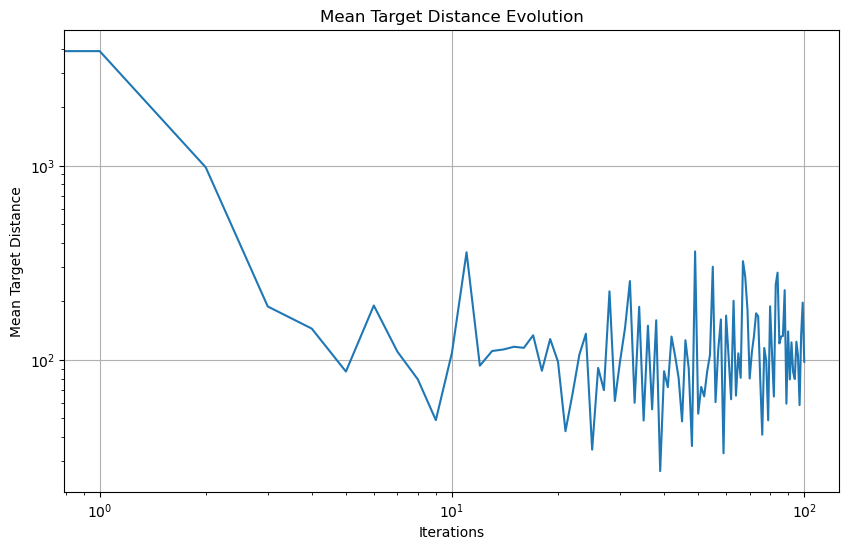

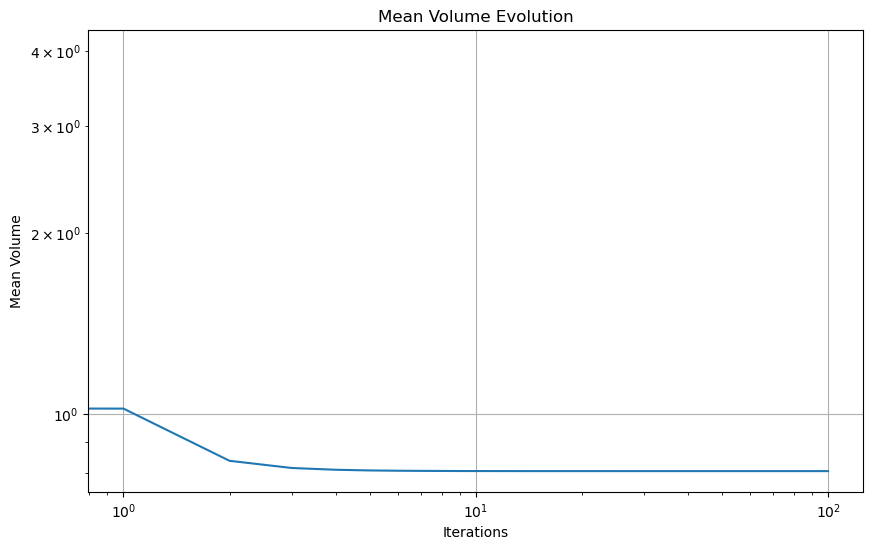

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()